# PHARMACEUTICAL MANUFACTURING QUALITY ANALYTICS

## 1. SETUP AND DATA LOADING

The dataset used for this analysis was previously cleaned and validated in Excel before being exported to CSV for analysis in Python. The cleaned dataset was imported from the project's data/cleaned directory.

In [1]:
# The relevant libraries to support analysis were imported. File location of cleaned CSV file was also confirmed.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
print (os.getcwd())

import os
print(os.listdir('c:/Users/marle/Documents/pharmaceutical_manufacturing_quality/data/cleaned'))

c:\Users\marle\Documents\pharmaceutical_manufacturing_quality\python
['pharma_manufacturing_cleaned.csv.csv']


In [2]:
df = pd.read_csv('c:/Users/marle/Documents/pharmaceutical_manufacturing_quality/data/cleaned/pharma_manufacturing_cleaned.csv.csv')


## 2. DATA QUALITY AND VALIDATION

Validation checks were performed to confirm that the cleaned dataset had been imported as expected, including dataset dimensions, duplicate records, previously identified missing values and categorical consistency. Data types were also reviewed and converted where appropriate, including conversion of batch dates to datetime format.

### 2.1 Dataset Structure

In [3]:
# The number of rows and columns was first examined to confirm the full dataset had been imported. Expected result was 3000 rows and 22 columns
df.shape

(3000, 22)

In [4]:
# In addition to the number, the names of the columns were also examined to confirm they had been imported as expected
df.columns

Index(['Batch_ID', 'Product', 'Manufacturing_Line', 'Batch_Date', 'Year',
       'Operator_Team', 'Temperature_C', 'Humidity_Percent',
       'Mixing_Speed_RPM', 'Mixing_Time_Minutes', 'Production_Time_Hours',
       'API_Assay_Percent', 'pH', 'Viscosity_cP', 'Dissolution_30min_Percent',
       'Yield_Percent', 'Batch_Status', 'Failure_Flag', 'Deviation_Flag',
       'Deviation_Rate_Flag', 'Deviation_Type', 'Deviation_Severity'],
      dtype='str')

In [5]:
# The first 5 entries were then inspected as a sample of how the complete dataset would look following importing
df.head()

,Batch_ID,Product,Manufacturing_Line,Batch_Date,Year,Operator_Team,Temperature_C,Humidity_Percent,Mixing_Speed_RPM,Mixing_Time_Minutes,...,pH,Viscosity_cP,Dissolution_30min_Percent,Yield_Percent,Batch_Status,Failure_Flag,Deviation_Flag,Deviation_Rate_Flag,Deviation_Type,Deviation_Severity
0,B001613,COX-2 Inhibitor,Line 3,27-Nov-2024,2024,Team D,22.30,45.13,324.0,39.0,...,6.65,112.1,89.88,92.33,Pass,0,No,0,NaN,NaN
1,B000736,COX-2 Inhibitor,Line 3,14-May-2024,2024,Team A,23.21,42.42,358.0,52.9,...,NaN,117.6,86.92,89.45,Pass,0,Yes,1,Equipment,Minor
2,B001121,COX-2 Inhibitor,Line 3,12-Mar-2024,2024,Team A,22.21,37.84,363.0,53.6,...,6.50,140.3,85.87,89.63,Pass,0,No,0,NaN,NaN
3,B002798,GLP-1 Agonist,Line 3,21-Aug-2024,2024,Team D,20.91,37.19,345.0,50.0,...,6.58,143.1,84.79,97.88,Pass,0,No,0,NaN,NaN
4,B001181,COX-2 Inhibitor,Line 3,14-Apr-2024,2024,Team C,23.44,42.48,320.0,19.8,...,6.70,98.0,92.55,89.81,Pass,0,No,0,NaN,NaN


### 2.2 Missing Values

In [6]:
# The total number of missing values was assessed. Expected result was 2% missing values for columns as confirmed in cleaning work performed in Excel
# Columns with missing values: Temperature, Humidity, Assay, pH, Viscosity & Dissolution
# Note: batches with no deviation reported would also show as N/A and consequently their Deviation Flag would also be N/A
df.isna().sum()

Batch_ID                        0
Product                         0
Manufacturing_Line              0
Batch_Date                      0
Year                            0
Operator_Team                   0
Temperature_C                  60
Humidity_Percent               60
Mixing_Speed_RPM                0
Mixing_Time_Minutes             0
Production_Time_Hours           0
API_Assay_Percent              60
pH                             60
Viscosity_cP                   60
Dissolution_30min_Percent      60
Yield_Percent                   0
Batch_Status                    0
Failure_Flag                    0
Deviation_Flag                  0
Deviation_Rate_Flag             0
Deviation_Type               2783
Deviation_Severity           2783
dtype: int64

### 2.3 Duplicate Records

In [7]:
# The total number of duplicate rows was examined. Expected result was 0 following previous cleaning work performed in Excel
df.duplicated().sum()

np.int64(0)

### 2.4 Categorical Validation

In [8]:
# The Product category was assessed to confirm the presence of 4 unqiue product types. Total count should equate to 3000
df['Product'].value_counts()


Product
Antidepressant     856
GLP-1 Agonist      804
AED                672
COX-2 Inhibitor    668
Name: count, dtype: int64

In [9]:
# The Manufacturing Line category was assessed to confirm the presence of 3 unique lines. Total count should equate to 3000
df['Manufacturing_Line'].value_counts()

Manufacturing_Line
Line 1    1079
Line 2     977
Line 3     944
Name: count, dtype: int64

In [10]:
# The Operator Team category was assessed to confirm the presence of 4 unique teams. Total count should equate to 3000
df['Operator_Team'].value_counts()

Operator_Team
Team B    776
Team A    757
Team C    751
Team D    716
Name: count, dtype: int64

In [11]:
# The Pass/Failed Batch Status was assessed to confirm the 2 possible outcomes. Total count should equate to 3000
df['Batch_Status'].value_counts()

Batch_Status
Pass      2899
Failed     101
Name: count, dtype: int64

In [12]:
# The Deviation Flag confirming if a deviation had been raised or not was assessed to confirm the 2 possiblt outcomes. Total count should equate to 3000
df["Deviation_Flag"].value_counts()

Deviation_Flag
No     2783
Yes     217
Name: count, dtype: int64

In [13]:
# Product types were confirmed once more to ensure there were only 4 unique options in the dataset and that typos were not present
df['Product'].unique()

<StringArray>
['COX-2 Inhibitor', 'GLP-1 Agonist', 'Antidepressant', 'AED']
Length: 4, dtype: str

### 2.5 Data Type Conversion

In [14]:
# Data Types were analysed for each column to determine if they were suitable for further analytics.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Batch_ID                   3000 non-null   str    
 1   Product                    3000 non-null   str    
 2   Manufacturing_Line         3000 non-null   str    
 3   Batch_Date                 3000 non-null   str    
 4   Year                       3000 non-null   int64  
 5   Operator_Team              3000 non-null   str    
 6   Temperature_C              2940 non-null   float64
 7   Humidity_Percent           2940 non-null   float64
 8   Mixing_Speed_RPM           3000 non-null   float64
 9   Mixing_Time_Minutes        3000 non-null   float64
 10  Production_Time_Hours      3000 non-null   float64
 11  API_Assay_Percent          2940 non-null   float64
 12  pH                         2940 non-null   float64
 13  Viscosity_cP               2940 non-null   float64
 14  Dis

In [15]:
# Following a review of the data types, it was decided that Batch Date would be converted from str to datetime
df['Batch_Date'] = pd.to_datetime(df['Batch_Date'])
df['Batch_Date'].dtype

dtype('<M8[us]')

In [16]:
# Conversion to data type for Batch Date was then confirmed
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Batch_ID                   3000 non-null   str           
 1   Product                    3000 non-null   str           
 2   Manufacturing_Line         3000 non-null   str           
 3   Batch_Date                 3000 non-null   datetime64[us]
 4   Year                       3000 non-null   int64         
 5   Operator_Team              3000 non-null   str           
 6   Temperature_C              2940 non-null   float64       
 7   Humidity_Percent           2940 non-null   float64       
 8   Mixing_Speed_RPM           3000 non-null   float64       
 9   Mixing_Time_Minutes        3000 non-null   float64       
 10  Production_Time_Hours      3000 non-null   float64       
 11  API_Assay_Percent          2940 non-null   float64       
 12  pH               

## 3. EXPLORATORY DATA ANALYSIS

Initial exploratory analysis was conducted to understand the distributions and variability of numerical process and performance measures. Descriptive statistics and outlier assessments were used to identify measurements warranting further investigation. Yield and Production Time distributions were also compared across products to identify patterns in manufacturing performance.

### 3.1 Numerical Summary

In [17]:
# An initial summary of the dataset was performed for the key batch variables. 
# Any variable with a noticably high range would then be assessed further for possible outliers.
process_cols = [
    'Temperature_C',
    'Humidity_Percent',
    'Mixing_Speed_RPM',
    'Production_Time_Hours',
    'API_Assay_Percent',
    'pH',
    'Viscosity_cP',
    'Dissolution_30min_Percent',
    'Yield_Percent'
]

df[process_cols].describe()

,Temperature_C,Humidity_Percent,Mixing_Speed_RPM,Production_Time_Hours,API_Assay_Percent,pH,Viscosity_cP,Dissolution_30min_Percent,Yield_Percent
count,2940.000000,2940.000000,3000.000000,3000.000000,2940.000000,2940.000000,2940.000000,2940.00000,3000.000000
mean,21.910405,42.131745,318.557333,7.327867,99.037391,6.855282,129.556190,87.07881,93.598617
std,0.871488,5.261591,22.666450,0.737904,0.309696,0.172679,12.869177,2.65440,1.489409
min,14.000000,8.000000,244.000000,4.740000,98.050000,6.300000,45.000000,78.86000,88.770000
25%,21.360000,38.600000,303.000000,6.840000,98.830000,6.730000,120.975000,85.23000,92.617500
50%,21.890000,42.100000,318.000000,7.310000,99.040000,6.860000,129.400000,87.04000,93.580000
75%,22.470000,45.572500,334.000000,7.820000,99.240000,6.980000,138.000000,88.88000,94.582500
max,31.500000,75.000000,392.000000,9.800000,101.800000,7.390000,280.000000,99.35000,99.220000


### 3.2 Outlier Assessment

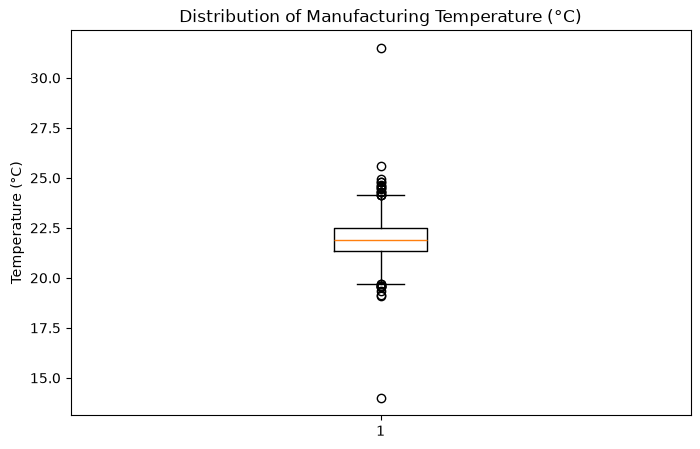

In [18]:
# Temperature was identified as having an unexpectedly high range in values which could be associated with outliers
# A box and whisker plot to visualise the extend of the data spread was produced
import pandas as pd

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.boxplot(df['Temperature_C'].dropna())
plt.ylabel('Temperature (°C)')
plt.title('Distribution of Manufacturing Temperature (°C)')
plt.show()

In [19]:
# To support the visualisation, the key boundary values of the box plot were calculated
Q1 = df['Temperature_C'].quantile(0.25)
Q3 = df['Temperature_C'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Q1: 21.36
Q3: 22.47
IQR: 1.1099999999999994
Lower Bound: 19.695
Upper Bound: 24.134999999999998


In [20]:
# To assess the impact of the temperature outliers, all batches outside of the lower and upper bounds were identified
temperature_outliers = df[(df['Temperature_C'] < lower_bound) | (df['Temperature_C'] > upper_bound)]

temperature_outliers[['Batch_ID', 'Product', 'Manufacturing_Line', 'Temperature_C', 'Batch_Status', 
                     'Deviation_Flag', 'Deviation_Type']
]


,Batch_ID,Product,Manufacturing_Line,Temperature_C,Batch_Status,Deviation_Flag,Deviation_Type
18,B001844,AED,Line 2,24.14,Pass,No,NaN
127,B000460,COX-2 Inhibitor,Line 3,24.93,Pass,No,NaN
228,B002273,COX-2 Inhibitor,Line 3,24.77,Pass,No,NaN
394,B000689,COX-2 Inhibitor,Line 2,24.43,Pass,No,NaN
550,B000419,Antidepressant,Line 1,19.55,Pass,No,NaN
646,B000216,COX-2 Inhibitor,Line 3,24.55,Failed,No,NaN
759,B000328,GLP-1 Agonist,Line 3,19.10,Failed,No,NaN
816,B002800,COX-2 Inhibitor,Line 2,25.61,Pass,No,NaN
958,B001585,COX-2 Inhibitor,Line 3,24.14,Failed,Yes,Environmental
1154,B002423,COX-2 Inhibitor,Line 3,24.14,Pass,No,NaN


In [21]:
# To aid with analysis, the identified batches were ranked by Temperature in ascending order
temperature_outliers[
    ['Batch_ID', 'Temperature_C', 'Manufacturing_Line', 'Batch_Status', 'Deviation_Flag', 'Deviation_Type'
]].sort_values(by='Temperature_C')

,Batch_ID,Temperature_C,Manufacturing_Line,Batch_Status,Deviation_Flag,Deviation_Type
1782,B002968,14.00,Line 1,Pass,Yes,Process
759,B000328,19.10,Line 3,Failed,No,NaN
1286,B001942,19.16,Line 1,Pass,No,NaN
1498,B002854,19.34,Line 1,Pass,No,NaN
2469,B002171,19.53,Line 3,Pass,No,NaN
550,B000419,19.55,Line 1,Pass,No,NaN
2667,B002936,19.57,Line 2,Failed,Yes,Equipment
1727,B000978,19.60,Line 1,Pass,No,NaN
1837,B001489,19.61,Line 1,Pass,No,NaN
1695,B002286,19.69,Line 1,Pass,No,NaN


In [22]:
# To focus in on the "extreme" outliers, the use of z-values was implemented to identify which batches had Temperature values > 3 standard deviations from the mean
temp_mean = df['Temperature_C'].mean()
temp_std = df['Temperature_C'].std()

df['Temperature_Z'] = ((df['Temperature_C'] - temp_mean) / temp_std)

df.loc[df['Temperature_Z'].abs() > 3, 
       ['Batch_ID', 'Temperature_C', 'Temperature_Z', 
        'Batch_Status', 'Deviation_Flag', 'Deviation_Type']
        ]. sort_values(by='Temperature_Z')

,Batch_ID,Temperature_C,Temperature_Z,Batch_Status,Deviation_Flag,Deviation_Type
1782,B002968,14.00,-9.076895,Pass,Yes,Process
759,B000328,19.10,-3.224835,Failed,No,NaN
1286,B001942,19.16,-3.155987,Pass,No,NaN
646,B000216,24.55,3.028837,Failed,No,NaN
2199,B000258,24.58,3.063261,Pass,No,NaN
1914,B000947,24.62,3.109160,Pass,No,NaN
228,B002273,24.77,3.281279,Pass,No,NaN
2725,B001036,24.80,3.315703,Pass,No,NaN
127,B000460,24.93,3.464873,Pass,No,NaN
816,B002800,25.61,4.245148,Pass,No,NaN


In [23]:
# As most of the Temperature values identified were only slightly above the >3 std threshold, it was concluded that only the 14C and 31.5C recordings were true outliers
# Outliers for the remaining batch variables were tabulated to identify any other areas of interest 
outlier_summary = []

for column in process_cols:
    result = identify_iqr_outliers(df, column)
    outlier_summary.append(result)

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

NameError: name 'identify_iqr_outliers' is not defined

In [ ]:
# With an outlier count of 23, Assay was next analysed. Batches that produced Assay values outside of the upper and lower bounds were tabulated and ordered
# Despite falling outside of the bounds, the spread of Assay values was still tight (98.1 - 101.8%) and none were deemed authentic outliers

Q1 = df['API_Assay_Percent'].quantile(0.25)
Q3 = df['API_Assay_Percent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

assay_outliers = df[(df['API_Assay_Percent'] < lower_bound) | (df['API_Assay_Percent'] > upper_bound)]

assay_outliers[['Batch_ID', 'Product', 'Manufacturing_Line', 'API_Assay_Percent', 'Batch_Status',
                'Deviation_Flag', 'Deviation_Type']].sort_values(by='API_Assay_Percent')

### 3.3 Product Performance

In [ ]:
# For a holistic view of how each product compared to one another, a box plot comparing yield distribution by product was plotted
plt.figure(figsize=(10, 6))

df.boxplot(
    column='Yield_Percent',
    by='Product'
)

plt.title('Yield Distribution by Product')
plt.suptitle('')
plt.xlabel('Product')
plt.ylabel('Yield (%)')
plt.xticks(rotation=20)
plt.show()

In [ ]:
# To support the visualisation, the key statistical values were tabulated
# With the collected data, an initial observation could be made that the GLP-1 Agonist product had the lowest overall performance
yield_by_product = df.groupby('Product')
yield_by_product = df.groupby('Product')['Yield_Percent'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

yield_by_product.round(2)

### 3.4 Manufacturing Line Performance

In [ ]:
# The performance of each Manufacturing Line was then assessed using another box plot comparing yield distribution
# The intention was to determine if the previously identified product performance could be concentrated to a certain area
plt.figure(figsize=(10, 6))

df.boxplot(
    column='Yield_Percent',
    by='Manufacturing_Line'
)

plt.title('Yield Distribution by Manufacturing Line')
plt.suptitle('')
plt.xlabel('Manufacturing Line')
plt.ylabel('Yield (%)')
plt.xticks(rotation=20)
plt.show()

In [ ]:
# To support the visualisation, the key statistical values were tabulated
yield_by_product = df.groupby('Manufacturing_Line')
yield_by_product = df.groupby('Manufacturing_Line')['Yield_Percent'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

yield_by_product.round(2)

In [ ]:
# To further assess Manufacturing Line performance, another KPI of Production Time was introduced and plotted replacing Yield on the y-axis
plt.figure(figsize=(8, 5))

df.boxplot(
    column='Production_Time_Hours',
    by='Manufacturing_Line'
)

plt.title('Production Time Distribution by Manufacturing Line')
plt.suptitle('')
plt.xlabel('Manufacturing Line')
plt.ylabel('Production Time (Hours)')
plt.show()

In [ ]:
# To support the visualisation, the key statistical values were tabulated
# Using both Yield and Production Time as KPIs, an initial observation could be made that Line 3 had the longest production time and lowest mean yield
production_time_by_line = df.groupby('Manufacturing_Line')['Production_Time_Hours'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max'])

production_time_by_line.round(2)

## 4. PROCESS VARIABLE RELATIONSHIP

Building on the exploratory analysis, Pearson correlation coefficients were used to assess linear relationships between numerical process and performance variables. Stronger aggregate relationships were investigated further through stratified analysis to determine whether they persisted across products and manufacturing lines.

### 4.1 Correlation Analysis

In [ ]:
# A Pearson correlation coefficient matrix was plotted comparing batch variables for possible linear relationships
correlation_matrix = df[process_cols].corr()
correlation_matrix.round(2)

In [ ]:
# To aid with analysis, the 10 largest correlation coefficients were extracted using their absolute values
import numpy as np

corr = df[process_cols].corr()

upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

strongest_correlations = (upper_triangle.stack().reset_index())

strongest_correlations.columns = ['Variable_1', 'Variable_2', 'Correlation']

strongest_correlations['Absolute_Correlation']= (strongest_correlations['Correlation'].abs())

strongest_correlations = strongest_correlations.sort_values(by='Absolute_Correlation', ascending=False)

strongest_correlations.head(10)

### 4.2 Production Time and Viscosity

In [ ]:
# With the highest identifed correlation coefficient, the possible relationship between Product Time and Viscosity was first assessed by scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Production_Time_Hours'],
    df['Viscosity_cP'],
    alpha=0.4
)

plt.xlabel('Production Time (Hours)')
plt.ylabel('Viscosity (cP)')
plt.title('Production Time vs. Viscosity')
plt.show()  

### 4.3 Stratification by Product and Manufacturing Line

In [ ]:
# Each product would have its own physiochemical properties that could naturally result in different viscosities
# The manufacturing processes would also differ between products for explainable reasons like number of steps required etc.
# Consequently, analysis was stratified by product to determine if the correlation coefficient would remain similar when plotting individual product viscosities and production times
products = df['Product'].unique()

for product in products:
    product_data = df[df['Product'] == product]
    
    correlation = product_data[['Production_Time_Hours', 'Viscosity_cP']].corr().iloc[0, 1]

    print(f'{product}: {correlation:.3f}')

In [ ]:
# With correlation coefficients noticably decreasing when stratifying analysis by product, the possible relationship was explored again by Manufacturing Line
# Here, the correlation coefficient remained somewhat constant at ~0.43 eluding to a possible relationship
lines = df['Manufacturing_Line'].unique()

for lines in lines:
    line_data = df[df['Manufacturing_Line'] == lines]
    
    correlation = line_data[['Production_Time_Hours', 'Viscosity_cP']].corr().iloc[0, 1]

    print(f'{lines}: {correlation:.3f}')

## 5. BATCH FAILURE ANALYSIS

Process and performance measures were compared between passed and failed batches to identify variables showing the greatest separation between batch outcome. The strongest observed differences were subsequently investigated using statistical tests and stratified analysis.

### 5.1 Process and Performance Differences by Batch Status

In [ ]:
# Mean values for batch variables were tabulated and segregated by Batch Status to determine any difference between passed and failed batches
failure_comparison = (
    df.groupby('Batch_Status')[process_cols].mean().T
)

failure_comparison = (
    df.groupby('Batch_Status')[process_cols].mean().T
)

failure_comparison['Difference'] = failure_comparison['Failed'] - failure_comparison['Pass']
failure_comparison.round(2)
failure_comparison.round(2)


In [ ]:
# Standardisation was applied so that each batch varable was being measured to a similar scale to allow for the difference between means to be more infomative
failure_comparison = (
    df.groupby('Batch_Status')[process_cols].mean().T
)

failure_comparison['Difference'] = failure_comparison['Failed'] - failure_comparison['Pass']

failure_comparison['Overall_SD'] = df[process_cols].std()

failure_comparison['Standardized_Difference'] = failure_comparison['Difference'] / failure_comparison['Overall_SD']

failure_comparison[
    ['Pass', 'Failed', 'Difference', 'Overall_SD', 'Standardized_Difference']
].round(3).sort_values(
    'Standardized_Difference',
    key=abs,
    ascending=False
)

### 5.2 Yield and Batch Status

In [ ]:
# With Yield appearing to have the largest difference in mean(passed) and mean(failed), the yield distribution by batch status was plotted for visualisation
# As expected, the box plot could visualise that failed batches had a lower mean yield compared to passed batches
plt.figure(figsize=(7, 5))
df.boxplot(
    column='Yield_Percent',
    by='Batch_Status'
)

plt.title('Yield Distribution by Batch Status')
plt.suptitle('')
plt.xlabel('Batch Status')
plt.ylabel('Yield (%)')
plt.show()

In [ ]:
# With Production Time having the second highest difference between mean(passed) and mean(failed) this too was plotted to visualise the disparity
# Once again, the box plot could visualise that failed batches had a higher mean production time compared to passed batches
plt.figure(figsize=(7, 5))
df.boxplot(
    column='Production_Time_Hours',
    by='Batch_Status'
)

plt.title('Production Time Distribution by Batch Status')
plt.suptitle('')
plt.xlabel('Batch Status')
plt.ylabel('Production Time (Hours)')
plt.show()

In [ ]:
# It was then time to determine if the difference in mean between passed and failed batches for yield and production time were statistically significant
# A Welch's t-test was first performed for yield and batch status
# With a t-statistic of 4.156 and a p-value < 0.001, using a 5% threshold, the null hypothesis had to be rejected
# There was a significant difference between the mean yield of passed batches versus the mean yield of failed batches
import pip
import sys
import subprocess


subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])

import scipy.stats as stats
from scipy.stats import ttest_ind

passed_yield = df.loc[
df['Batch_Status'] == 'Pass', 'Yield_Percent'
].dropna()

failed_yield = df.loc[
df['Batch_Status'] == 'Failed', 'Yield_Percent'
].dropna()

t_stat, p_value = ttest_ind(
    passed_yield, 
    failed_yield, 
    equal_var=False
)

print(f'T-statistic: {t_stat:.3f}')
print(f'P-value: {p_value:.3f}')

In [ ]:
# The same t-test was performed for production time and batch status
# With a t-statistic of -1.973 and a p-value = 0.051, using a 5% threshold, rejection of the null hypothesis failed
# A significant difference between the mean production time of passed batches and mean production time of failed batches could not be confirmed
passed_production_time = df.loc[
df['Batch_Status'] == 'Pass', 'Production_Time_Hours'
].dropna()

failed_production_time = df.loc[
df['Batch_Status'] == 'Failed', 'Production_Time_Hours'
].dropna()

t_stat, p_value = ttest_ind(
    passed_production_time,
    failed_production_time,
    equal_var=False
)

print(f'T-statistic: {t_stat:.3f}')
print(f'P-value: {p_value:.3f}')

### 5.3 Yield Analysis by Product

In [ ]:
# As was done before with batch variables, the mean yield was assessed by product and segregated by batch status to identify differences between passed ad failed batches
yield_by_product_status = (
    df.groupby(['Product', 'Batch_Status'])['Yield_Percent']
    .agg(['count', 'mean', 'median', 'std']).round(2)
)

yield_by_product_status

In [ ]:
# Once again, a t-test was performed using yield and batch status for each product to identify any possible statistical significance
# Using the same 5% threshold and from the collected p-values, it was possible to reject the null hypothesis for the GLP-1 Agonist, AED and Antidepressant products
# For the COX-2 Inhibitor product, rejection of the null hypothesis failed with the resulting p value = 0.542
from scipy.stats import ttest_ind

product_test_results = []

for product in df['Product'].unique():
    product_data = df[df['Product'] == product]
    
    passed = product_data.loc[
        product_data['Batch_Status'] == 'Pass', 'Yield_Percent'
    ].dropna()
    
    failed = product_data.loc[
        product_data['Batch_Status'] == 'Failed', 'Yield_Percent'
    ].dropna()
    
    t_stat, p_value = ttest_ind(
        passed,
        failed,
        equal_var=False
    )
    
    product_test_results = []

    for product in df['Product'].unique():
        product_data = df[df['Product'] == product]

        passed = product_data.loc[
            product_data['Batch_Status'] == 'Pass', 'Yield_Percent'
        ].dropna()

        failed = product_data.loc[
            product_data['Batch_Status'] == 'Failed', 'Yield_Percent'
        ].dropna()

        t_stat, p_value = ttest_ind(
            passed,
            failed,
            equal_var=False
        )

        product_test_results.append({
            'Product': product,
            'Pass_n': len(passed),
            'Fail_n': len(failed),
            'Pass_Mean': passed.mean(),
            'Failed_Mean': failed.mean(),
            'Mean_Difference': failed.mean() - passed.mean(),
            'T-statistic': t_stat,
            'P-value': p_value
        })

product_test_results = pd.DataFrame(product_test_results)
product_test_results.round(3)


### 5.4 Yield Analysis by Manufacturing Line

In [ ]:
# A similar assessment comparing mean yield for passed and failed batches was performed for the manufacturing lines
# From the resulting t-test, it was possible to reject the null hypothesis for Line 3 only using the same 5% threshold
# Therefore, only Line 3 showed a statistically significant difference between the mean yield of passed batches versus the mean yield of failed batches
line_test_results = []

line_test_results = []

for line in df['Manufacturing_Line'].unique():
    line_data = df[df['Manufacturing_Line'] == line]

    passed = line_data.loc[
        line_data['Batch_Status'] == 'Pass',
        'Yield_Percent'
    ].dropna()

    failed = line_data.loc[
        line_data['Batch_Status'] == 'Failed',
        'Yield_Percent'
    ].dropna()

    t_stat, p_value = ttest_ind(
        passed,
        failed,
        equal_var=False
    )

    line_test_results.append({
        'Manufacturing_Line': line,
        'Pass_n': len(passed),
        'Fail_n': len(failed),
        'Pass_Mean': passed.mean(),
        'Failed_Mean': failed.mean(),
        'Mean_Difference': failed.mean() - passed.mean(),
        'T-statistic': t_stat,
        'P-value': p_value
    })

line_test_results = pd.DataFrame(line_test_results)
line_test_results.round(3)
    
passed = line_data.loc[
        line_data['Batch_Status'] == 'Pass', 'Yield_Percent'
    ].dropna()
    
failed = line_data.loc[
        line_data['Batch_Status'] == 'Failed', 'Yield_Percent'
    ].dropna()
    
t_stat, p_value = ttest_ind(
        passed,
        failed,
        equal_var=False
    )
    
line_test_results = pd.concat(
    [
        line_test_results,
        pd.DataFrame([{
            'Manufacturing_Line': line,
            'Pass_n': len(passed),
            'Fail_n': len(failed),
            'Pass_Mean': passed.mean(),
            'Failed_Mean': failed.mean(),
            'Mean_Difference': failed.mean() - passed.mean(),
            'T-statistic': t_stat,
            'P-value': p_value
        }])
    ],
    ignore_index=True
)

line_test_results = pd.DataFrame(line_test_results)
line_test_results.round(3)

### 5.5 Failure Rate by Yield Quartile

In [ ]:
# To understand if failure rates changed across yield levels, the data set was split into yield quartiles
# The number of batches per quartile were first confirmed to ensure a representative batch size existed for all four quadrants
if 'df' not in globals():
    df = pd.read_csv(
        'c:/Users/marle/Documents/pharmaceutical_manufacturing_quality/data/cleaned/pharma_manufacturing_cleaned.csv.csv'
    )

df['Yield_Quartile'] = pd.qcut(
    df['Yield_Percent'],
    q=4,
    labels=['Q1 - Lowest', 'Q2', 'Q3', 'Q4 - Highest']
)

df['Yield_Quartile'].value_counts().sort_index()

In [ ]:
# Once the count was confirmed, the number of failed batches and consequently the failure rate % were tabulated
yield_quartile_failure_rates = (
    df.groupby('Yield_Quartile', observed=True)
      .agg(
          Total_Batches=('Batch_ID', 'count'),
          Failed_Batches=('Batch_Status', lambda x: (x == 'Failed').sum())
      )
)

yield_quartile_failure_rates['Failure_Rate_Percent'] = (
    yield_quartile_failure_rates['Failed_Batches']
    / yield_quartile_failure_rates['Total_Batches']
    * 100
)

yield_quartile_failure_rates

In [ ]:
# The clear drop in failure rate percent upon increasing yield was then tabulated using a bar chart as this would be a key analytical insight
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    yield_quartile_failure_rates.index,

    yield_quartile_failure_rates['Failure_Rate_Percent'],
    color='skyblue'
)

plt.title('Batch Failure Rate by Yield Quartile')
plt.xlabel('Yield Quartile')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=15)
plt.show()

## 6. DEVIATION ANALYSIS

Failure rates were compared between batches with and without recorded deviations to assess whether deviation status was associated with batch outcome. Deviation types were then examined by frequency and associated failure rate, followed by further investigation of Process deviations across manufacturing lines.

### 6.1 Deviation Status and Batch Failure

In [ ]:
# Batch Status was assessed using Deviation Flag to get a broad understanding of the failure rate of batches with deviations recorded and those without 
deviation_failure_table = pd.crosstab(
    df['Deviation_Flag'],
    df["Batch_Status"]
)

deviation_failure_table

In [ ]:
# A chi-squared test was then conducted to analyse any possible relationship between Batch Status and Deviation Flag
# The resulting p-value of < 0.0001 mean that the null hypothesis could be rejected
# There was therefore a statistically significant association between Batch Status and Deviation Flag

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(deviation_failure_table)

print(f'Chi-square statistic: {chi2:.3f}')
print(f'P-value: {p_value:.6f}')
print(f'Degrees of freedom: {dof}')

In [ ]:
# With the association characterised, the phi coefficient was calculated to determine the strength of the relationship
# With ϕ = 0.101, it was possible to conclude that the assocation was weak
import numpy as np

n = deviation_failure_table.to_numpy().sum()

phi = np.sqrt(chi2 / n)

print(f'Phi coefficient: {phi:3f}')

### 6.2 Deviation Type

In [ ]:
# Deviations were then analysed by their separate types to distinguish if certain classes of deviations were occurring more frequently than others
deviation_batches = df[df['Deviation_Flag'] == 'Yes'].copy()

deviation_type_summary = (
    deviation_batches.groupby('Deviation_Type').agg
    (Total_Batches=('Batch_ID', "count"), Failed_Batches=('Batch_Status', lambda x: (x == "Failed").sum()))
)

deviation_type_summary['Failure_Rate_Percent'] = (
    deviation_type_summary["Failed_Batches"] / deviation_type_summary['Total_Batches'] * 100
)

deviation_type_summary.sort_values(
    'Failure_Rate_Percent', ascending=False
).round(2)

,Total_Batches,Failed_Batches,Failure_Rate_Percent
Deviation_Type,,,
Process,74,9,12.16
Equipment,48,5,10.42
Documentation,20,2,10.00
Environmental,42,4,9.52
Material,33,2,6.06


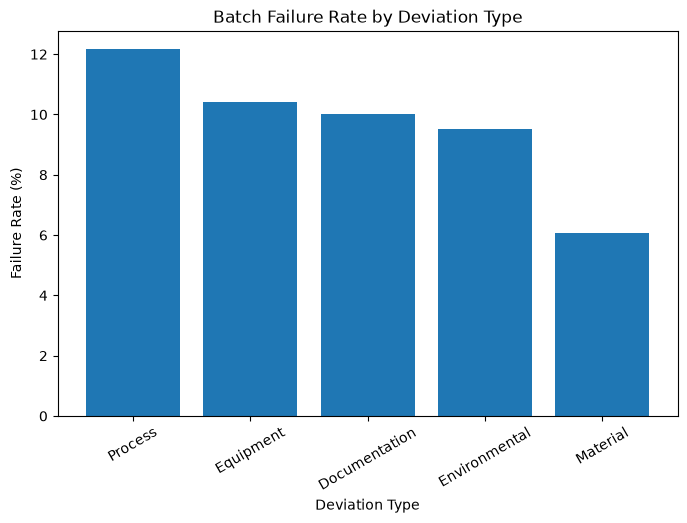

In [ ]:
# Failure rate % associated with each deviation type was then plotted on a bar chart to identify if a certain type should be prioritised for analysis
deviation_type_plot = deviation_type_summary.sort_values('Failure_Rate_Percent', ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(deviation_type_plot.index, deviation_type_plot['Failure_Rate_Percent'])

plt.title('Batch Failure Rate by Deviation Type')
plt.xlabel('Deviation Type')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=30)
plt.show()

### 6.3 Process Deviations by Manufacturing Line

In [ ]:
# With Process Deviations having the highest frequency, higest number of associated failed batches and highest failure rate %, this type was investigated
# The next step was to understand if process deviations were occuring at a highest frequency on a certain line - Line 3 previously being flagged for lower performance
process_deviations = df[(df["Deviation_Flag"] == 'Yes') & (df['Deviation_Type'] == 'Process' )].copy()

process_by_line = (
    process_deviations.groupby('Manufacturing_Line')
    .agg(
        Process_Deviations=('Batch_ID', 'count'),
        Failed_Batches=('Batch_Status', lambda x: (x == 'Failed').sum())
    )
)

process_by_line['Failure_Rate_Percent'] = (
    process_by_line['Failed_Batches']
    / process_by_line['Process_Deviations']
    * 100
)

process_by_line.round(2)

process_by_line['Failure_Rate_Percent'] = (
    process_by_line['Failed_Batches'] / process_by_line['Process_Deviations'] * 100)

process_by_line.round(2)

,Process_Deviations,Failed_Batches,Failure_Rate_Percent
Manufacturing_Line,,,
Line 1,24,1,4.17
Line 2,31,5,16.13
Line 3,19,3,15.79


In [ ]:
# Interestingly, despite the previously identified performance issues observed on Line 3, it was Line 2 that experienced the greatest challenges with Process Deviations
# Process deviations alone, therefore, cannot explain Line 3's performance issues
line_totals = df.groupby('Manufacturing_Line')['Batch_ID'].count()

process_by_line['Total_Line_Batches'] = line_totals

process_by_line['Process_Deviation_Rate_Percent'] = (process_by_line['Process_Deviations'] / process_by_line['Total_Line_Batches'] * 100)

process_by_line.round(2)

,Process_Deviations,Failed_Batches,Failure_Rate_Percent,Total_Line_Batches,Process_Deviation_Rate_Percent
Manufacturing_Line,,,,,
Line 1,24,1,4.17,1079,2.22
Line 2,31,5,16.13,977,3.17
Line 3,19,3,15.79,944,2.01


## 7. OPERATOR TEAM ASSESSMENT

Operator Team was assessed as a potential source of variation in manufacturing outcomes by comparing average yield, production time, failure rates and deviation rates across teams. Product and manufacturing line allocation were also examined to determine whether differences in workload distribution could influence apparent team-level patterns.

In [ ]:
# Team performance was tabulated by comparing each Operator Team to the manufacturing performance KPIs
team_performance = (
    df.groupby('Operator_Team').agg(
        Total_Batches=('Batch_ID', 'count'),
        Failed_Batches=('Batch_Status', lambda x: (x == 'Failed').sum()),
        Deviations=('Deviation_Flag', lambda x: (x == 'Yes').sum()),
        Average_Yield=('Yield_Percent', 'mean'),
        Average_Production_Time=('Production_Time_Hours', 'mean')
    )
)
team_performance['Failure_Rate_Percent'] = (
    team_performance['Failed_Batches'] / team_performance['Total_Batches'] * 100
)

team_performance['Deviation_Rate_Percent'] = (
    team_performance['Deviations'] / team_performance['Total_Batches'] * 100
)

team_performance.round(2)

,Total_Batches,Failed_Batches,Deviations,Average_Yield,Average_Production_Time,Failure_Rate_Percent,Deviation_Rate_Percent
Operator_Team,,,,,,,
Team A,757,27,57,93.65,7.30,3.57,7.53
Team B,776,28,63,93.60,7.36,3.61,8.12
Team C,751,24,45,93.60,7.31,3.20,5.99
Team D,716,22,52,93.54,7.34,3.07,7.26


In [ ]:
# With seemingly little to identify a specific team as performance issues, manufacturing line allocation was assessed
# The objective was to see if a particular team spent a majority of the time on Line 3
team_line_mix = pd.crosstab(
    df['Operator_Team'],
    df['Manufacturing_Line'],
    normalize='index'
) * 100

team_line_mix.round(1)  

Manufacturing_Line,Line 1,Line 2,Line 3
Operator_Team,,,
Team A,38.2,32.1,29.7
Team B,34.9,32.2,32.9
Team C,32.8,34.4,32.9
Team D,38.1,31.6,30.3


In [ ]:
# With all teams having a broad distribution across all lines, the same analysis was performed assessing allocation by Product 
# The objective was to see if a particular team spent a majority of the time manufacturing the GLP-1 Agonist product
# As with the manufacturing line allocation, product allocation across teams was also fairly broad - further investigation into Operators teams was therefore deprioritised
team_line_mix = pd.crosstab(
    df['Operator_Team'],
    df['Product'],
    normalize='index'
) * 100

team_line_mix.round(1)  

Product,AED,Antidepressant,COX-2 Inhibitor,GLP-1 Agonist
Operator_Team,,,,
Team A,23.5,26.9,23.0,26.6
Team B,23.7,29.5,20.4,26.4
Team C,21.8,29.6,22.6,26.0
Team D,20.4,28.1,23.2,28.4


## 8. ANALYTICAL CONCLUSIONS

1. Of all factors assessed, yield showed the clearest association with batch status. Failed batches had significantly lower mean yield than passed batches (p < 0.001). A graded relationship was also observed across yield quartiles, with the failure rate decreasing progressively from 6.27% in the lowest-yield quartile to 1.60% in the highest.

2. The overall yield-failure relationship could not be explained simply by product or manufacturing line. Failed batches recorded lower mean yield across all three manufacturing lines, although the difference reached the 5% statistically significant threshold for Line 3. At product level, failed batches had significantly lower mean yield for three of the four products examined. These subgroup results should be interpreted cautiously due to the relatively small number of failed batches.

3. Deviation status was significantly associated with batch status. Batches with a recorded deviation had an observed failure rate of 10.1% compared to 2.84% for batches without a deviation. The association was statistically significant (χ2(1) = 30.765, p < 0.0001), although the overall strength of association was weak (ϕ = 0.101). This suggests that deviation status is a useful indicator of elevated failure risk but does not, by itself, explain batch failure.

4. Process deviations represent a priority for further investigation, recording the highest frequency (74 deviations), the greatest number associated with failed batches (9), and the highest observed failure rate among deviation types (12.2%). Process deviations occurred across all three manufacturing lines, however, and therefore do not provide a specific explanation for Line 3's poorer overall performance.

5. Some aggregate relationships between process variables were substantially influenced by operational grouping. Production Time and Viscosity showed a moderate positive correlation across all batches (r = 0.433), but this relationship weakened significantly when analysed separately by product (r = 0.114 - 0.199). This demonstrates the importance of considering product-level differences before interpreting aggregate process correlations.
